¡Simulación con regiones oscilatorias y planas completada con éxito!
Grados de libertad libres: 801


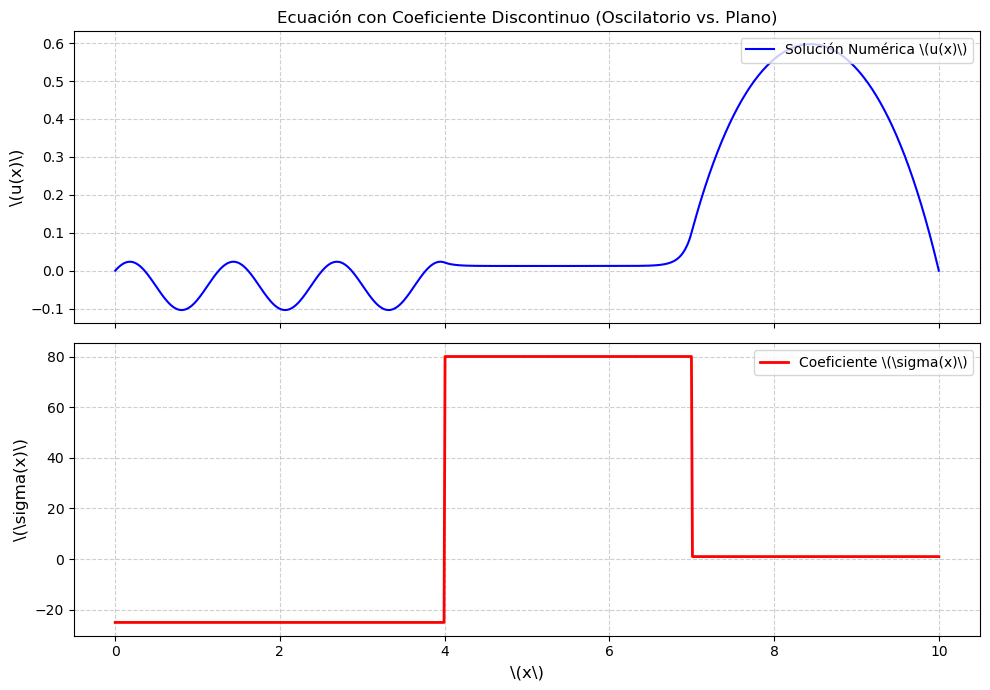

In [1]:
from ngsolve import *
from ngsolve.meshes import Make1DMesh
import numpy as np
import matplotlib.pyplot as plt

# 1. Construcción de una malla 1D más fina para resolver adecuadamente las oscilaciones
L = 10.0
mesh = Make1DMesh(400, mapping=lambda x: x * L, periodic=False)

# 2. Espacio de Elementos Finitos (H1 de orden 2) con Dirichlet homogéneo en los extremos
V = H1(mesh, order=2, dirichlet="left|right")
u = V.TrialFunction()
v = V.TestFunction()

# 3. Definición del coeficiente discontinuo sigma(x) con cambio de signo:
# - Si x < 4.0: sigma = -25.0 (Comportamiento ondulatorio / oscilatorio tipo Helmholtz)
# - Si 4.0 <= x <= 7.0: sigma = 80.0 (Alta reacción / atenuación -> región casi plana)
# - Si x > 7.0: sigma = 1.0 (Comportamiento estándar de difusión)
x_cf = CoefficientFunction(x)
sigma = IfPos(4.0 - x_cf, -25.0, IfPos(7.0 - x_cf, 80.0, 1.0))

# Término fuente f(x) constante
f_source = 1.0

# 4. Formulación variacional: -u'' + sigma*u = f
a = BilinearForm(V)
a += (grad(u) * grad(v) + sigma * u * v) * dx

f = LinearForm(V)
f += f_source * v * dx

# 5. Ensamblaje y Resolución del Sistema Lineal
with TaskManager():
    a.Assemble()
    f.Assemble()
    gfu = GridFunction(V)
    # Nota: Para problemas indefinidos o con regiones negativas de sigma, 
    # nos aseguramos de que el sistema sea invertible (evitando modos propios puros si es necesario).
    gfu.vec.data = a.mat.Inverse(V.FreeDofs()) * f.vec

print("¡Simulación con regiones oscilatorias y planas completada con éxito!")
print(f"Grados de libertad libres: {V.ndof}")

# 6. Post-procesamiento y Visualización dual con Matplotlib
x_plot = np.linspace(0, L, 800)
u_plot = [gfu(mesh(xi, 0, 0)) for xi in x_plot]
sigma_plot = [sigma(mesh(xi, 0, 0)) for xi in x_plot]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Gráfica de la solución u(x)
ax1.plot(x_plot, u_plot, 'b-', linewidth=1.5, label='Solución Numérica \(u(x)\)')
ax1.set_ylabel('\(u(x)\)', fontsize=12)
ax1.set_title('Ecuación con Coeficiente Discontinuo (Oscilatorio vs. Plano)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# Gráfica del coeficiente discontinuo sigma(x)
ax2.plot(x_plot, sigma_plot, 'r-', linewidth=2, label='Coeficiente \(\sigma(x)\)')
ax2.set_xlabel('\(x\)', fontsize=12)
ax2.set_ylabel('\(\sigma(x)\)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

¡Simulación de alta oscilación completada con éxito!
Grados de libertad libres: 1201


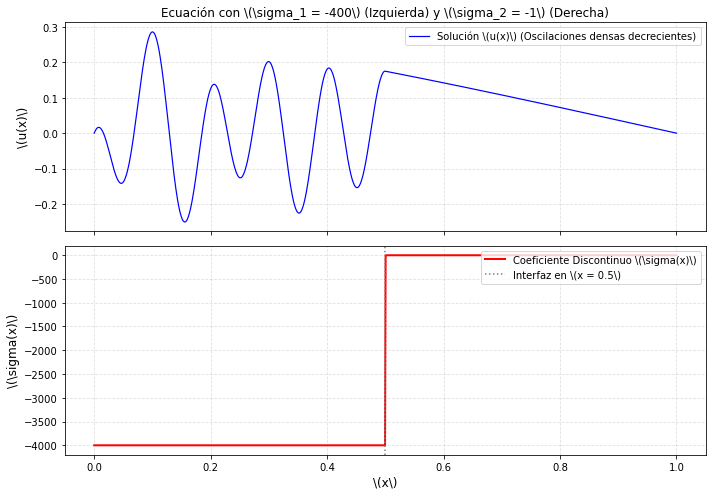

In [18]:
from ngsolve import *
from ngsolve.meshes import Make1DMesh
import numpy as np
import matplotlib.pyplot as plt

# 1. Construcción de una malla 1D más fina en [0, 1] para resolver altas frecuencias
L = 1.0
mesh = Make1DMesh(600, mapping=lambda x: x * L, periodic=False)

# 2. Espacio de Elementos Finitos (H1 de orden 2) con Dirichlet homogéneo en los extremos
V = H1(mesh, order=2, dirichlet="left|right")
u = V.TrialFunction()
v = V.TestFunction()

# 3. Definición del coeficiente discontinuo sigma(x) en el dominio [0, 1]
# - Izquierda (x < 0.5): sigma = -400.0 (Alto número de onda -> alta oscilación)
# - Derecha (x >= 0.5): sigma = -1.0
x_cf = CoefficientFunction(x)
sigma = IfPos(0.5 - x_cf, -4000.0, -1.0)

# 4. Término fuente con alta frecuencia y amplitud decreciente (envolvente exponencial) en la izquierda
# f_source = exp(-4*x) * cos(35*x) para la región izquierda, y 0 para la derecha
f_source = IfPos(0.5 - x_cf, 500.0 * exp(-4.0 * x_cf) * cos(35.0 * x_cf), 0.0)

# 5. Formulación variacional: -u'' + sigma*u = f
a = BilinearForm(V)
a += (grad(u) * grad(v) + sigma * u * v) * dx

f = LinearForm(V)
f += f_source * v * dx

# 6. Ensamblaje y Resolución del Sistema Lineal
with TaskManager():
    a.Assemble()
    f.Assemble()
    gfu = GridFunction(V)
    gfu.vec.data = a.mat.Inverse(V.FreeDofs()) * f.vec

print("¡Simulación de alta oscilación completada con éxito!")
print(f"Grados de libertad libres: {V.ndof}")

# 7. Post-procesamiento y Visualización dual con Matplotlib
x_plot = np.linspace(0, L, 1000)
u_plot = [gfu(mesh(xi, 0, 0)) for xi in x_plot]
sigma_plot = [sigma(mesh(xi, 0, 0)) for xi in x_plot]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Gráfica de la solución u(x) con alta oscilación decreciente
ax1.plot(x_plot, u_plot, 'b-', linewidth=1.2, label='Solución \(u(x)\) (Oscilaciones densas decrecientes)')
ax1.set_ylabel('\(u(x)\)', fontsize=12)
ax1.set_title('Ecuación con \(\sigma_1 = -400\) (Izquierda) y \(\sigma_2 = -1\) (Derecha)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper right')

# Gráfica del coeficiente discontinuo sigma(x)
ax2.plot(x_plot, sigma_plot, 'r-', linewidth=2, label='Coeficiente Discontinuo \(\sigma(x)\)')
ax2.axvline(x=0.5, color='gray', linestyle=':', label='Interfaz en \(x = 0.5\)')
ax2.set_xlabel('\(x\)', fontsize=12)
ax2.set_ylabel('\(\sigma(x)\)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()